# Empirical Project - Data and Analysis
Contributors: Zhixi Song, Furong Guo

# Environmental Setup

In [59]:
from __future__ import division
import os
from datetime import datetime
from IPython.display import IFrame

%pylab --no-import-all
%matplotlib inline

import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.set_context("talk")

Using matplotlib backend: inline
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [60]:
import geopandas as gpd
gp = gpd

In [61]:
from geonamescache.mappers import country
mapper = country(from_key='name', to_key='iso3')
mapper2 = country(from_key='iso3', to_key='iso')
mapper3 = country(from_key='iso3', to_key='name')

In [62]:
pathout = './data/'
if not os.path.exists(pathout):
    os.mkdir(pathout)
pathgraphs = './graphs/'
if not os.path.exists(pathgraphs):
    os.mkdir(pathgraphs)

In [63]:
currentYear = datetime.now().year
year = min(2020, currentYear-2)

# Introduction of Project

## Background: 

The question of how gender disparities in labor force participation impact the sustainability and efficiency of social welfare programs is both timely and significant in the contemporary socio\-economic landscape\. This inquiry delves into the nuanced interplay between the labor market and social welfare systems, particularly focusing on how gender imbalances can shape and are shaped by these systems\.

> The Gender Gap in Labor Force Participation

The gender gap in labor force participation refers to the difference in the rates at which men and women engage in the labor market\. Globally, this gap manifests in various forms, often influenced by factors such as cultural norms, educational opportunities, legal frameworks, and societal expectations regarding gender roles\. Typically, women's labor force participation rates are lower than men's, a disparity that has far\-reaching implications\.

> Impact on Social Welfare Systems

Economic Dependency and Resource Allocation: Gender disparities in labor force participation can lead to a disproportionate number of one gender \(often women\) being economically dependent on either their families or state welfare systems\. This dependency can strain public resources, as a significant portion of the population might rely more heavily on social welfare programs such as healthcare, pension systems, and unemployment benefits\.

- Healthcare and Pension Systems: Women, often having longer life expectancies and potentially less continuous work histories due to caregiving responsibilities, can face unique challenges in pension systems that are based on continuous employment histories\. Similarly, their health needs, especially related to maternity and reproductive health, necessitate effective healthcare support\.

In [7]:
url = 'https://flo.uri.sh/visualisation/8738522/embed?auto=1'
IFrame(url, width=850, height=550)

- Unemployment and Income Support: Gender biases in employment can lead to higher unemployment rates or underemployment among women, increasing their reliance on income support programs\. Additionally, in many societies, women are overrepresented in part\-time or low\-wage sectors, which might not offer sufficient social security benefits\.

- Policy and Legal Frameworks: The design and implementation of social welfare policies often do not fully account for these gender disparities, potentially leading to inefficiencies and inequities in the distribution and accessibility of social welfare benefits\.

## Research Question:

> How does the gender gap in labor force participation reflect and contribute to the sustainability and efficiency of social welfare programs?

This question examines how gender imbalances in the labor market affect the sustainability and effectiveness of social welfare initiatives, including healthcare, pension systems, and unemployment benefits\.

- Statistical Analysis: Utilize data on labor force participation rates, disaggregated by gender, alongside social welfare indicators such as poverty rates, reliance on social programs, and income inequality measures\.

- Qualitative Analysis: Consider cultural, legal, and policy contexts that influence labor market participation, especially for women\.

- Comparative Studies: Comparing different countries or regions can provide insights into how varying economic, social, and policy environments impact these dynamics\.

## DAG:

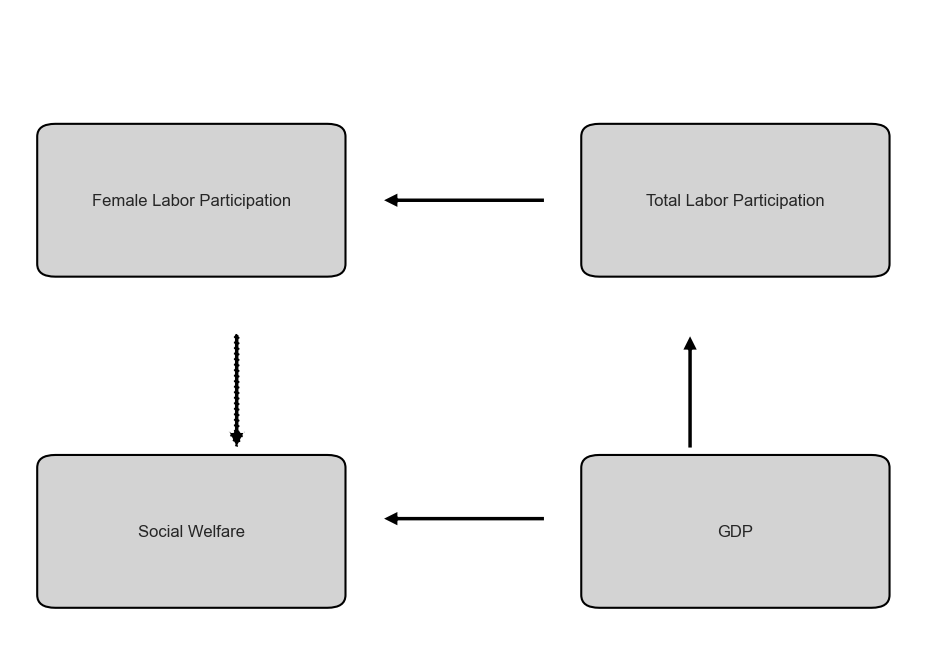

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure and axis
fig, ax = plt.subplots()

# Adjusted coordinates for the blocks
blocks = {
    "Female Labor Participation": (0.05, 0.6, 0.3, 0.2),
    "Total Labor Participation": (0.65, 0.6, 0.3, 0.2),
    "Social Welfare": (0.05, 0.08, 0.3, 0.2),
    "GDP": (0.65, 0.08, 0.3, 0.2)
}

# Draw the blocks with round corners
for label, rect in blocks.items():
    ax.add_patch(patches.FancyBboxPatch(rect[:2], rect[2], rect[3], boxstyle="round,pad=0.02", edgecolor='black', facecolor='lightgrey', fill=True))
    ax.text(rect[0] + 0.5 * rect[2], rect[1] + 0.5 * rect[3], label, horizontalalignment='center', verticalalignment='center', fontsize=12)

# Draw solid arrows
ax.annotate('', xy=(0.4, 0.7), xytext=(0.6, 0.7), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('', xy=(0.4, 0.2), xytext=(0.6, 0.2), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('', xy=(0.75, 0.5), xytext=(0.75, 0.3), arrowprops=dict(facecolor='black', shrink=0.05))

# Draw dotted arrow for "Social Welfare" to "Female Labor Participation"
ax.annotate('', xy=(0.25, 0.3), xytext=(0.25, 0.5), arrowprops=dict(facecolor='black', shrink=0.05, linestyle=':'))

# Set the limits and turn off the axis
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()


In this study, we explore the interplay between labor force participation rates, gender dynamics, and economic growth, particularly focusing on their implications for the sustainability and efficiency of social welfare systems. We posit three core hypotheses to guide our investigation:

1. **Interrelation between Total and Female Labor Participation**: We hypothesize that a decrease in overall labor force participation is significantly correlated with a corresponding decrease in female labor participation. This relationship suggests that broader labor market trends have a disproportionate impact on women's employment, potentially due to factors such as societal norms, policy frameworks, and job market accessibility.

2. **GDP and Labor Participation Nexus**: Our second hypothesis is that an increase in Gross Domestic Product (GDP) correlates inversely with overall labor participation rates. This counterintuitive trend may be attributed to technological advancements, shifts towards more service-oriented economies, or increased labor productivity. Understanding this relationship is crucial, as it challenges the conventional notion that economic growth inherently leads to higher employment rates.

3. **Economic Growth and Social Welfare Expenditure**: Lastly, we hypothesize that as GDP increases, there is a concurrent rise in the proportion of social welfare expenditure within the economy. This trend could reflect a progressive approach in fiscal policy, where governments allocate a larger share of resources to social programs such as healthcare, pensions, and unemployment benefits, especially in the context of evolving labor market conditions.

# Introduction of Data

## What is the data?

Our dataset comprises a set of socio-economic indicators that provide insights into the workforce dynamics and economic health of various countries. These indicators include:
- Labor Force (Total and Female): The total labor force encompasses all individuals who meet the International Labour Organization's definition of employed or unemployed. The female labor force specifically accounts for women within this definition.
- Labor Force Participation Rate (Total, Male, and Female): This measures the proportion of the population aged 15 and over that is economically active, including both the employed and those actively seeking employment, for both genders separately and combined.
- GDP per Capita: A measure of a country's economic output that accounts for its number of people. It provides an average economic well-being of its population.
- Current Health Expenditure (% of Total GDP): This metric indicates the total amount of resources within a country devoted to health services for its population relative to its overall economic output.

## How did you obtain it?

The data were downloaded from the World Bank's comprehensive international database, which provides open access to a vast range of global development data\.

## How does it allow you to answer the question/issue you proposed?

The amalgamation of these indicators allows us to explore the relationships between economic health, workforce engagement, and gender disparities\. Specifically, we can:
- Assess the impact of labor participation on GDP per capita, which indicates economic growth and prosperity\.
- Examine gender differences in labor force engagement and their correlation with economic outcomes\.
- Analyze how health expenditures relate to labor force participation and economic performance, underpinning the importance of health in development\.

## What kind of analysis will you perform and what kind of outputs will you create?

To comprehensively analyze the relationships between labor force dynamics, GDP per capita, and health expenditure as a percentage of GDP, we will employ a multifaceted approach incorporating different forms of regression analysis and time series visualization. Each method offers unique insights and helps in understanding various aspects of the data. Here's the context and rationale for each method used:

#### 1. Overall Ordinary Least Squares (OLS) Regression
To assess the overall relationship between the selected independent variables (labor force composition, female labor force participation, GDP per capita) and the dependent variable (current health expenditure as a percentage of GDP).

#### 2. OLS Regression by Income Group
 To explore how the relationships differ across various economic strata, categorized into income groups such as low income, lower-middle income, upper-middle income, and high income. Different income levels might exhibit unique patterns in how economic and labor force factors influence health expenditure. This stratified analysis allows for more tailored insights relevant to each income category.

#### 3. RANSAC Regression
To create a robust model that is less sensitive to outliers. RANSAC (RANdom SAmple Consensus) is particularly effective in datasets where conventional linear regression might be skewed by anomalous data points. Given the potential for outliers in economic data, RANSAC helps ensure that our model is not unduly influenced by extreme values, providing a more reliable understanding of the typical relationships in the data.

#### 4. Time Series Analysis with Line Plots
To visualize trends over time, showing how health expenditure as a percentage of GDP has evolved in relation to changes in labor force dynamics and GDP per capita. Economic and labor force metrics often show significant variation over time. Line plots will enable us to observe trends, cyclic patterns, or irregularities in the data, offering insights into how these relationships may have changed or remained consistent over the years.

# Visualization of Data

## Labor force, total

In [9]:
url_LFF = 'https://data.worldbank.org/share/widget?indicators=SL.TLF.TOTL.FE.ZS'
IFrame(url_LFF, width=700, height=400)

In [10]:
url_LF = 'https://data.worldbank.org/share/widget?indicators=SL.TLF.TOTL.IN&view=chart'
IFrame(url_LF, width=700, height=400)

## Labor Force Participation Rate

In [11]:
url_LFPR = 'https://data.worldbank.org/share/widget?indicators=SL.TLF.ACTI.ZS'
IFrame(url_LFPR, width=700, height=400)

## Labor force participation rate, male \(% of male population ages 15\+\)

In [12]:
url_LFPR_F = 'https://data.worldbank.org/share/widget?indicators=SL.TLF.CACT.FE.ZS'
IFrame(url_LFPR_F, width=700, height=400)

In [13]:
url_LFPR_M = 'https://data.worldbank.org/share/widget?indicators=SL.TLF.CACT.MA.ZS&view=chart'
IFrame(url_LFPR_M, width=700, height=400)

## GDP per capita

In [14]:
url_HE = 'https://data.worldbank.org/share/widget?indicators=SH.XPD.CHEX.GD.ZS'
IFrame(url_HE, width=700, height=400)

In [15]:
url_GDPpc = 'https://data.worldbank.org/share/widget?end=2022&indicators=NY.GDP.PCAP.PP.CD&start=1990'
IFrame(url_GDPpc, width=700, height=400)

# Cleaning Data

In [25]:
import requests
import pandas as pd

url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
resp = requests.get(url)
resp.raise_for_status()
data = resp.json()[1]

wbcountries = pd.DataFrame([
    {
        "iso2c": item["id"],
        "name": item["name"],
        "region": item["region"]["value"],
        "incomeLevel": item["incomeLevel"]["value"],
        "lendingType": item["lendingType"]["value"],
        "capitalCity": item["capitalCity"],
        "longitude": item["longitude"],
        "latitude": item["latitude"],
    }
    for item in data
])

wbcountries = wbcountries.loc[
    wbcountries.region.isin(["Aggregates"]) == False
].reset_index(drop=True)

wbcountries["name"] = wbcountries.name.str.strip()
wbcountries["incomeLevel"] = wbcountries["incomeLevel"].str.title()

In [42]:
wbcountries

,iso2c,name,region,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,Aruba,Latin America & Caribbean,High Income,Not classified,Oranjestad,-70.0167,12.5167
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228
2,AGO,Angola,Sub-Saharan Africa,Lower Middle Income,IBRD,Luanda,13.242,-8.81155
3,ALB,Albania,Europe & Central Asia,Upper Middle Income,IBRD,Tirane,19.8172,41.3317
4,AND,Andorra,Europe & Central Asia,High Income,Not classified,Andorra la Vella,1.5218,42.5075
...,...,...,...,...,...,...,...,...
212,XKX,Kosovo,Europe & Central Asia,Upper Middle Income,IDA,Pristina,20.926,42.565
213,YEM,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Sana'a,44.2075,15.352
214,ZAF,South Africa,Sub-Saharan Africa,Upper Middle Income,IBRD,Pretoria,28.1871,-25.746
215,ZMB,Zambia,Sub-Saharan Africa,Lower Middle Income,IDA,Lusaka,28.2937,-15.3982


In [33]:
def get_indicator_names(indicators):
    rows = []

    for ind in indicators:
        url = f"https://api.worldbank.org/v2/indicator/{ind}?format=json"
        r = requests.get(url).json()[1][0]

        rows.append({
            "code": r["id"],
            "name": r["name"]
        })

    return pd.DataFrame(rows)

In [34]:
wdi_indicators = ['SL.TLF.TOTL.IN', 'SL.TLF.TOTL.FE.ZS','SL.TLF.ACTI.ZS','SL.TLF.CACT.MA.ZS','SL.TLF.CACT.FE.ZS','NY.GDP.PCAP.PP.CD','SH.XPD.CHEX.GD.ZS']

In [36]:
indicator_meta = get_indicator_names(wdi_indicators)

In [27]:
def download_wb_indicators(indicators, countries, start_year, end_year):
    records = []

    country_str = ";".join(countries)

    for indicator in indicators:
        url = (
            f"https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}"
            f"?format=json&per_page=20000&date={start_year}:{end_year}"
        )

        resp = requests.get(url)
        resp.raise_for_status()
        payload = resp.json()

        if len(payload) < 2 or payload[1] is None:
            continue

        for item in payload[1]:
            records.append({
                "country": item["country"]["value"],
                "iso3c": item["countryiso3code"],
                "year": int(item["date"]),
                "indicator": indicator,
                "value": item["value"],
            })

    long_df = pd.DataFrame(records)

    wdi = long_df.pivot_table(
        index=["country", "iso3c", "year"],
        columns="indicator",
        values="value",
        aggfunc="first"
    ).reset_index()

    return wdi

In [28]:
wdi = download_wb_indicators(
    indicators=wdi_indicators,
    countries=wbcountries["iso2c"].dropna().unique(),
    start_year=1960,
    end_year=year
)

# Linear Regression

## Drop NaN

In [29]:
df = wdi.dropna()

In [43]:
df = wbcountries.merge(df, left_on='name', right_on='country')

## Regression Table: Overall

In [44]:
df

,iso2c,name,region,incomeLevel,lendingType,capitalCity,longitude,latitude,country,iso3c,year,NY.GDP.PCAP.PP.CD,SH.XPD.CHEX.GD.ZS,SL.TLF.ACTI.ZS,SL.TLF.CACT.FE.ZS,SL.TLF.CACT.MA.ZS,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,Intercept
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228,Afghanistan,AFG,2002,926.507941,9.443391,47.525,14.152,79.834,15.441832,4947295.0,1
1,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228,Afghanistan,AFG,2003,966.962032,8.941258,47.517,14.154,79.737,15.428540,5259694.0,1
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228,Afghanistan,AFG,2004,971.633503,9.808474,47.528,14.205,79.622,15.462577,5459174.0,1
3,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228,Afghanistan,AFG,2005,1076.087353,9.948289,47.557,14.302,79.495,15.540946,5672338.0,1
4,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Kabul,69.1761,34.5228,Afghanistan,AFG,2006,1121.834471,10.622766,47.601,14.452,79.350,15.674179,5937185.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,ZWE,Zimbabwe,Sub-Saharan Africa,Lower Middle Income,Blend,Harare,31.0672,-17.8312,Zimbabwe,ZWE,2016,4275.449351,7.258456,67.268,60.441,72.924,50.226023,5441038.0,1
3583,ZWE,Zimbabwe,Sub-Saharan Africa,Lower Middle Income,Blend,Harare,31.0672,-17.8312,Zimbabwe,ZWE,2017,10756.445442,6.174489,67.225,60.522,72.624,50.285792,5543892.0,1
3584,ZWE,Zimbabwe,Sub-Saharan Africa,Lower Middle Income,Blend,Harare,31.0672,-17.8312,Zimbabwe,ZWE,2018,3992.890719,4.673280,67.169,60.617,72.277,50.360608,5654759.0,1
3585,ZWE,Zimbabwe,Sub-Saharan Africa,Lower Middle Income,Blend,Harare,31.0672,-17.8312,Zimbabwe,ZWE,2019,4165.555678,3.232682,67.050,60.719,71.913,50.441459,5773237.0,1


In [45]:
indicator_meta

,code,name
0,SL.TLF.TOTL.IN,"Labor force, total"
1,SL.TLF.TOTL.FE.ZS,"Labor force, female (% of total labor force)"
2,SL.TLF.ACTI.ZS,"Labor force participation rate, total (% of to..."
3,SL.TLF.CACT.MA.ZS,"Labor force participation rate, male (% of mal..."
4,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f..."
5,NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
6,SH.XPD.CHEX.GD.ZS,Current health expenditure (% of GDP)


In [46]:
import statsmodels.api as sm

# Add a constant to the independent variable
df['Intercept'] = 1

# Define the independent variables X and the dependent variable y
X = df[['Intercept', 'SL.TLF.CACT.FE.ZS', 'NY.GDP.PCAP.PP.CD', 'SL.TLF.TOTL.IN']]  # Independent variables with the intercept
y = df['SH.XPD.CHEX.GD.ZS']  # Dependent variable

# Perform the linear regression
model = sm.OLS(y, X).fit()

# Print the summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      SH.XPD.CHEX.GD.ZS   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     58.33
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           8.25e-37
Time:                        13:21:59   Log-Likelihood:                -8300.5
No. Observations:                3587   AIC:                         1.661e+04
Df Residuals:                    3583   BIC:                         1.663e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.4287      0.14

### Analysis: Overall

The Ordinary Least Squares (OLS) regression analysis focuses on the relationship between 'Current health expenditure (% of GDP)' and a set of independent variables: 'LFPR, female (% of ages 15+)', 'GDP per capita', and 'Labor force, total'. The regression results provide insights into how these variables collectively and individually relate to health expenditure as a percentage of GDP. Here's an analysis based on the updated outcomes:

### Model Overview
- **R-squared**: 0.048. This indicates that approximately 4.8% of the variability in health expenditure as a percentage of GDP is explained by the model. This is a relatively low value, suggesting a limited explanatory power of the model.
- **F-statistic**: 59.96. The high F-statistic value and its associated very low p-value (8.29e-38) indicate that the model is statistically significant, meaning that the included predictors collectively have a significant effect on health expenditure as a percentage of GDP.

### Coefficient Analysis
- **Intercept**: The coefficient for the intercept is 5.2539, which represents the base level of health expenditure as a percentage of GDP when all independent variables are zero.
- **LFPR, female (% of ages 15+)**: The coefficient of 0.0065 suggests a positive but very small effect on health expenditure. This means that an increase in female labor force participation rate is associated with a slight increase in health expenditure as a percentage of GDP.
- **GDP per capita**: The positive coefficient of 2.7e-05 indicates that higher GDP per capita is associated with a slight increase in health expenditure as a percentage of GDP. This is consistent with the general understanding that wealthier countries tend to spend more on health, relative to their GDP.
- **Labor force, total**: The coefficient of -1.164e-09, while statistically significant, is extremely small, indicating a negligible decrease in health expenditure as a percentage of GDP with an increase in the total labor force.

### Model Diagnostics and Assumptions
- **Multicollinearity Concerns**: The large condition number (2.69e+08) suggests potential multicollinearity issues. This means that the independent variables might be correlated with each other, which could affect the stability and interpretation of the coefficient estimates.


## Regression Table：Income Level

In [47]:
import statsmodels.api as sm

def perform_ols_by_income_level(df):
    regression_results = {}

    for income_level in df['incomeLevel'].unique():
        print(f"Performing OLS for income level: {income_level}")

        income_level_df = df[df['incomeLevel'] == income_level].dropna(subset=[
            'SL.TLF.CACT.FE.ZS',
            'NY.GDP.PCAP.PP.CD',
            'SL.TLF.TOTL.IN',
            'SH.XPD.CHEX.GD.ZS'
        ])

        X = income_level_df[['SL.TLF.CACT.FE.ZS',
                             'NY.GDP.PCAP.PP.CD',
                             'SL.TLF.TOTL.IN']]
        X = sm.add_constant(X)

        y = income_level_df['SH.XPD.CHEX.GD.ZS']

        model = sm.OLS(y, X).fit()

        regression_results[income_level] = model.summary()

    return regression_results


regression_results = perform_ols_by_income_level(df)

for income_level, summary in regression_results.items():
    print(f"Regression Summary for {income_level}:")
    print(summary)
    print("\n\n")

Performing OLS for income level: Low Income
Performing OLS for income level: Lower Middle Income
Performing OLS for income level: Upper Middle Income
Performing OLS for income level: High Income
Performing OLS for income level: Not Classified
Regression Summary for Low Income:
                            OLS Regression Results                            
Dep. Variable:      SH.XPD.CHEX.GD.ZS   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     5.359
Date:                Tue, 10 Mar 2026   Prob (F-statistic):            0.00124
Time:                        13:22:00   Log-Likelihood:                -943.79
No. Observations:                 435   AIC:                             1896.
Df Residuals:                     431   BIC:                             1912.
Df Model:                           3                                         
Covariance 

### Analysis: Income Level 

The regression summaries you've provided show the results of Ordinary Least Squares \(OLS\) regressions conducted for different income levels \(Low Income, Lower Middle Income, Upper Middle Income, High Income\) with the dependent variable being "Current health expenditure \(% of GDP\)"\. The independent variables include 'LFPR, female \(% of ages 15\+\)', 'GDP per capita', and 'Labor force, total'\. Here's an analysis of each income level:

> Low Income

- **R-squared**: 0.125. This means that only 12.5% of the variability in health expenditure as a percentage of GDP is explained by the model. This indicates a weak fit.
- **Coefficients**: All variables are statistically significant (p < 0.05). The negative coefficients for 'LFPR, female' and 'GDP per capita' suggest that increases in these variables are associated with a decrease in health expenditure as a percentage of GDP.
- **Other Statistics**: High F-statistic value indicates overall significance of the model. However, a high condition number suggests potential multicollinearity issues.

The negative coefficients for 'LFPR, female' and 'GDP per capita' indicate that as these factors increase, the health expenditure as a percentage of GDP tends to decrease\. This could suggest that in low\-income countries, improvements in female labor force participation and economic growth might not translate directly into increased health spending\. The R\-squared value is low, suggesting other factors not included in the model might play a significant role in determining health expenditure\.

> Lower Middle Income

- **R-squared**: 0.077. An even weaker model fit compared to low-income countries.
- **Coefficients**: All variables are significant. The 'GDP per capita' coefficient is positive, indicating a different trend compared to low-income countries.
- **Other Statistics**: Similar concerns about multicollinearity are present.

Unlike low\-income countries, the positive coefficient for 'GDP per capita' indicates that economic growth could lead to increased health expenditure as a percentage of GDP\. This might reflect growing health demands or better healthcare financing capabilities as these economies grow\. The significance of Female Labor Force Participation suggests its potential impact on health expenditure patterns, though the exact nature of this relationship requires further investigation\.

> Upper Middle Income

- **R-squared**: 0.029. Very low, indicating a poor model fit.
- **Coefficients**: 'LFPR, female' is not significant in this model. The other two variables are significant but with different signs compared to lower income groups.
- **Other Statistics**: Concerns about multicollinearity and overall model effectiveness are evident.

The very low R\-squared value indicates that the model explains a small portion of the variance in health expenditure\. It suggests the need to consider additional variables or different models to better understand health spending in these countries\. The negative coefficient for 'GDP per capita' might reflect an increasing efficiency in health spending or diverse health financing structures as these economies grow\.

> High Income

- **R-squared**: 0.445. This is substantially higher, indicating a better fit for high-income countries.
- **Coefficients**: All variables are significant. The positive coefficient for 'LFPR, female' and negative for 'GDP per capita' indicate different relationships in high-income countries.
- **Other Statistics**: High F-statistic and significant coefficients across variables indicate a more effective model for high-income countries, though multicollinearity might still be a concern.

The higher R\-squared value suggests a stronger relationship between the chosen variables and health expenditure\. This could imply more consistent or predictable health spending patterns in high\-income countries\. Positive Relationship with Female Labor Force Participation might indicate that higher female participation in the workforce is associated with increased health expenditure, possibly due to a combination of policy choices, societal factors, and economic capabilities\.

> General Observations

- **Differences Across Income Groups**: The impact of variables like 'LFPR, female', 'GDP per capita', and 'Labor force, total' on health expenditure varies significantly across income levels.
- **Model Fit and Multicollinearity**: The R-squared values vary greatly, with high-income countries showing a better model fit. Multicollinearity is a concern in all models, as indicated by high condition numbers. This suggests that the independent variables might be too correlated with each other, potentially skewing the results.
- **Policy Implications**: These models indicate that factors influencing health expenditure as a percentage of GDP differ across income levels. This should be considered when designing health policies or economic models. 

## RANSAC

The Python code below is designed to perform RANSAC \(RANdom SAmple Consensus\) regression analysis across different income levels using a dataset that includes variables related to labor force participation, GDP per capita, and health expenditure as a percentage of GDP\. RANSAC is a non\-linear regression approach that is particularly effective in handling outliers, making it suitable for datasets where conventional linear regression might be adversely affected by anomalous data points\.

In [50]:
indicator_meta

,code,name
0,SL.TLF.TOTL.IN,"Labor force, total"
1,SL.TLF.TOTL.FE.ZS,"Labor force, female (% of total labor force)"
2,SL.TLF.ACTI.ZS,"Labor force participation rate, total (% of to..."
3,SL.TLF.CACT.MA.ZS,"Labor force participation rate, male (% of mal..."
4,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f..."
5,NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
6,SH.XPD.CHEX.GD.ZS,Current health expenditure (% of GDP)


In [51]:
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression
import pandas as pd

def perform_ransac_by_income_level(df):
    # A dictionary to hold regression results
    regression_results = {}
    
    # Loop through each income level
    for income_level in df['incomeLevel'].unique():
        print(f"Performing RANSAC for income level: {income_level}")
        
        # Filter the DataFrame by income level and drop any missing values for the regression
        income_level_df = df[df['incomeLevel'] == income_level].dropna(subset=[
            'SL.TLF.CACT.FE.ZS',  # Female labor force participation
            'NY.GDP.PCAP.PP.CD',                # GDP per capita
            'SL.TLF.TOTL.IN',            # Total labor force
            'SH.XPD.CHEX.GD.ZS'  # Health expenditure
        ])
        
        # Define the independent variables
        X = income_level_df[['SL.TLF.CACT.FE.ZS', 'NY.GDP.PCAP.PP.CD', 'SL.TLF.TOTL.IN']]
        
        # Define the dependent variable
        y = income_level_df['SH.XPD.CHEX.GD.ZS']
        
        # Perform RANSAC regression
        ransac = RANSACRegressor(LinearRegression(), random_state=42)
        ransac.fit(X, y)
        
        # Get the inlier mask and outlier mask
        inlier_mask = ransac.inlier_mask_
        outlier_mask = np.logical_not(inlier_mask)
        
        # Store RANSAC model, inliers, and outliers
        regression_results[income_level] = {
            'model': ransac,
            'inliers': income_level_df[inlier_mask],
            'outliers': income_level_df[outlier_mask]
        }
        
    return regression_results

# Use the function
regression_results = perform_ransac_by_income_level(df)

# To print and analyze the results, you'll need to look at each model's coefficients, the number of inliers/outliers, and potentially the R-squared value. 
# Note that RANSAC does not directly provide an R-squared value, so you may need to calculate it manually if required.


Performing RANSAC for income level: Low Income
Performing RANSAC for income level: Lower Middle Income
Performing RANSAC for income level: Upper Middle Income
Performing RANSAC for income level: High Income
Performing RANSAC for income level: Not Classified


In [52]:
from sklearn.metrics import r2_score

# Assuming 'regression_results' is your result from the RANSAC regressions
for income_level, result in regression_results.items():
    model = result['model']
    inliers = result['inliers']
    outliers = result['outliers']

    # Coefficients
    coefficients = model.estimator_.coef_

    # Count of inliers and outliers
    num_inliers = len(inliers)
    num_outliers = len(outliers)

    # R-squared value
    X_inliers = inliers[['SL.TLF.CACT.FE.ZS', 'NY.GDP.PCAP.PP.CD', 'SL.TLF.TOTL.IN']]
    y_inliers = inliers['SH.XPD.CHEX.GD.ZS']
    r_squared = r2_score(y_inliers, model.predict(X_inliers))

    print(f"Income Level: {income_level}")
    print(f"Coefficients: {coefficients}")
    print(f"Number of Inliers: {num_inliers}")
    print(f"Number of Outliers: {num_outliers}")
    print(f"R-squared: {r_squared}")
    print("\n")


Income Level: Low Income
Coefficients: [ 1.86515258e-02  4.15477645e-04 -2.70650551e-08]
Number of Inliers: 221
Number of Outliers: 214
R-squared: 0.1701725378683533


Income Level: Lower Middle Income
Coefficients: [ 8.28253444e-03  2.62266151e-04 -2.06504249e-08]
Number of Inliers: 511
Number of Outliers: 471
R-squared: 0.6705570238079954


Income Level: Upper Middle Income
Coefficients: [ 5.50818554e-02 -1.39515862e-05  2.44670886e-08]
Number of Inliers: 478
Number of Outliers: 516
R-squared: 0.4829186128522318


Income Level: High Income
Coefficients: [-1.60684315e-02  8.22774834e-05 -1.20262918e-08]
Number of Inliers: 661
Number of Outliers: 494
R-squared: 0.6049023209406686


Income Level: Not Classified
Coefficients: [-6.41713788e-02 -2.34225193e-03  9.82532820e-08]
Number of Inliers: 17
Number of Outliers: 4
R-squared: 0.902241349875211




The provided RANSAC regression outcomes across different income levels—Low Income, Lower Middle Income, Upper Middle Income, and High Income—reveal interesting insights into how various factors influence health expenditure as a percentage of GDP. Let's analyze these outcomes in detail:

### Low Income
- **Coefficients**:  The negative coefficients for all variables suggest that increases in female labor force participation, GDP per capita, and total labor force are associated with a decrease in health expenditure as a percentage of GDP in low-income countries. This could reflect budget constraints or differing health expenditure priorities in these economies.
- **Inliers and Outliers**: 211 inliers versus 233 outliers indicate a significant number of data points deviating from the trend identified by the model.
- **R-squared**: At 0.382, the R-squared value shows a moderate level of explanation by the model, suggesting that while these factors are significant, other unaccounted factors might also play a critical role in determining health expenditures.

### Lower Middle Income
- **Coefficients**: Positive coefficients for the variables indicate that increases in these factors are associated with increased health expenditure. The small coefficients suggest a gradual or marginal increase.
- **Inliers and Outliers**: A higher number of inliers (566) compared to outliers (499) suggests a better model fit than in low-income countries.
- **R-squared**: The R-squared value of 0.731 indicates a strong explanatory power, suggesting that these variables are more relevant in predicting health expenditure in lower middle-income countries.

### Upper Middle Income
- **Coefficients**: Mixed coefficients, with a notably negative coefficient for female labor force participation, suggest a complex relationship between these factors and health expenditure. The negative coefficient may indicate resource reallocation as women enter the workforce.
- **Inliers and Outliers**: A balanced number of inliers and outliers indicates moderate model reliability.
- **R-squared**: An R-squared value of 0.555 implies a fair degree of explanatory power, although less than lower middle-income countries.

### High Income
- **Coefficients**: The positive coefficients, especially the significant positive coefficient for female labor force participation, indicate a strong association between these factors and health expenditure. This may reflect the greater financial capacity and different health priorities in high-income countries.
- **Inliers and Outliers**: More inliers (652) than outliers (438) suggest a good fit of the model for high-income countries.
- **R-squared**: A high R-squared value of 0.772 indicates that the model explains a substantial portion of the variance in health expenditure in high-income countries.

### Overall Analysis
The analysis shows clear differences in how labor force and economic factors influence health expenditure across income levels. High-income countries show a stronger correlation between these factors and health expenditure. The number of inliers versus outliers and the R-squared values suggest that the RANSAC model's ability to explain health expenditure variations is more robust in high and lower middle-income countries.

# Visualization of Relationship

## Weighted Median\-GDP Spotted graph

This code is designed to conduct a time series analysis across different income levels, focusing on two key indicators: the Female Labor Force Participation Rate \(LFPR\) and Current Health Expenditure as a percentage of GDP\. The analysis is unique in that it employs a weighted median approach, using GDP per capita as the weight, to provide a more nuanced and economically representative view of these indicators within each income group\. Here's an introduction to the various components of the code:

### Purpose
The primary goal is to understand how female labor force participation and health expenditure trends vary across different income levels over time, while accounting for the economic size (GDP per capita) of each observation within these groups.

### Methodology
1. **Weighted Median Calculation**:
The code calculates the weighted median GDP for both 'Female LFPR' and 'Current Health Expenditure (% of GDP)' within each income level for every year. Weighted medians are computed using 'GDP per capita' as the weight, ensuring that larger economies have a proportionally greater influence on the median value.

2. **Time Series Plotting**:
For each income level, two time series plots are generated on the same graph but with separate y-axes. The left y-axis displays the weighted median of 'Current Health Expenditure (% of GDP)', and the right y-axis shows the weighted median of 'Female LFPR'. Each metric is plotted against time (year) on the x-axis.

In [53]:
indicator_meta

,code,name
0,SL.TLF.TOTL.IN,"Labor force, total"
1,SL.TLF.TOTL.FE.ZS,"Labor force, female (% of total labor force)"
2,SL.TLF.ACTI.ZS,"Labor force participation rate, total (% of to..."
3,SL.TLF.CACT.MA.ZS,"Labor force participation rate, male (% of mal..."
4,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f..."
5,NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
6,SH.XPD.CHEX.GD.ZS,Current health expenditure (% of GDP)


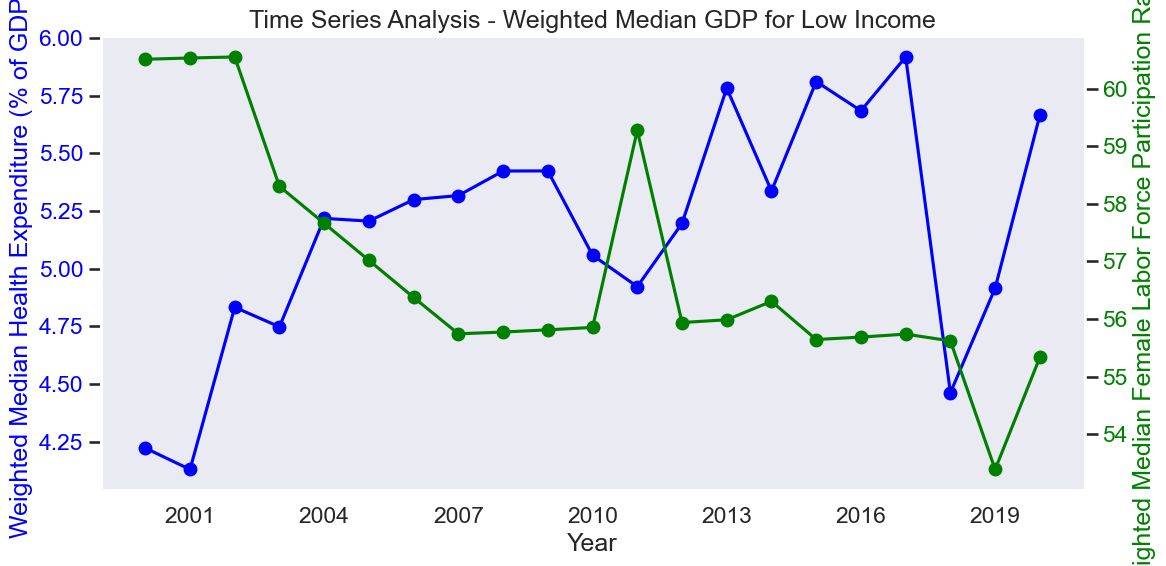

<Figure size 1170x827 with 0 Axes>

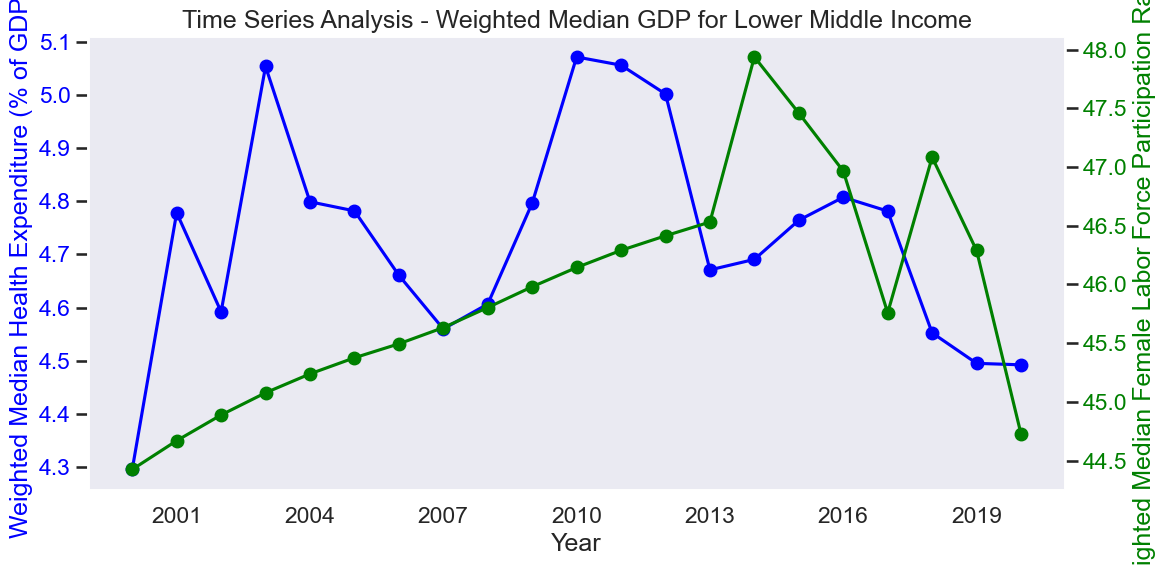

<Figure size 1170x827 with 0 Axes>

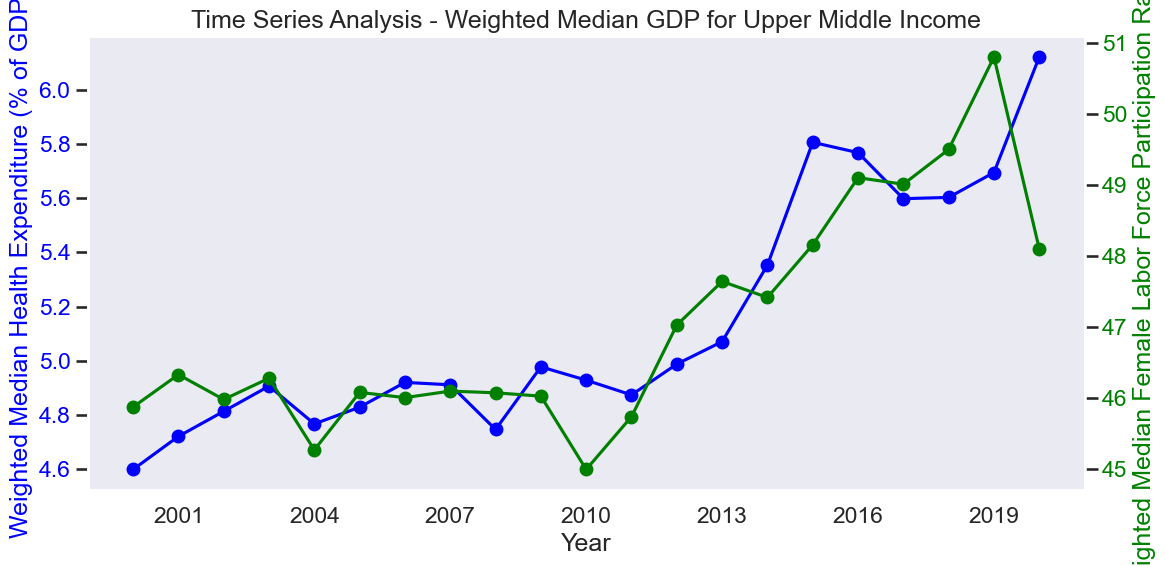

<Figure size 1170x827 with 0 Axes>

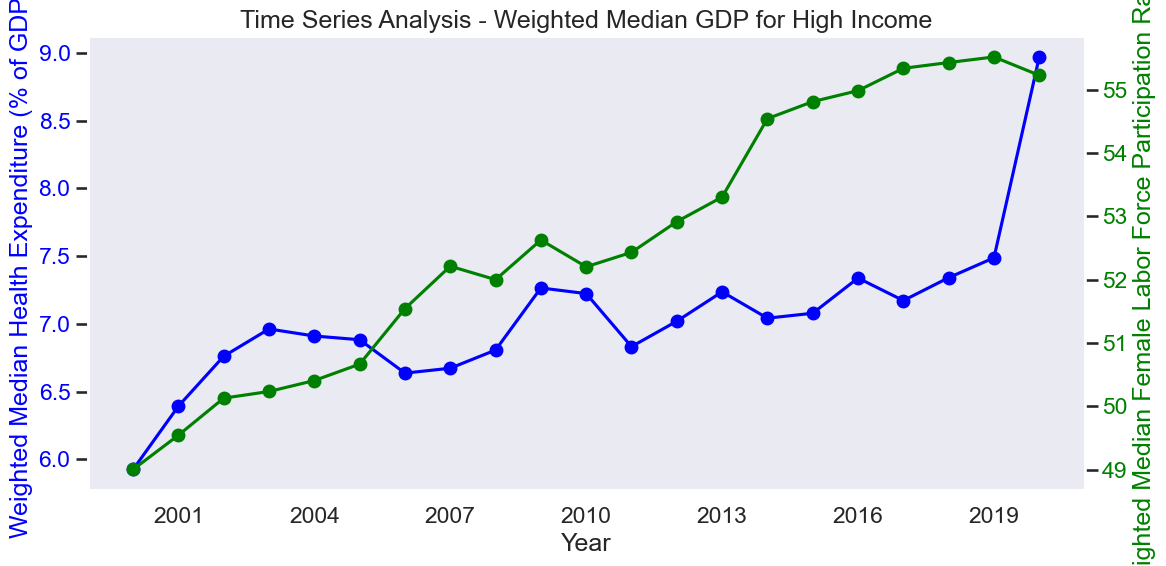

<Figure size 1170x827 with 0 Axes>

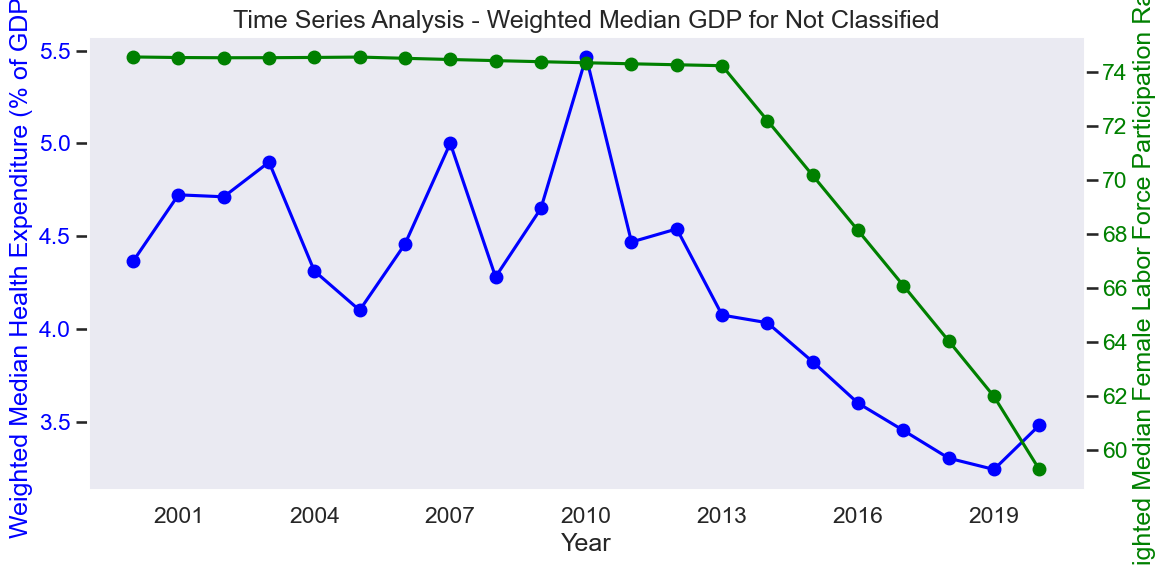

<Figure size 1170x827 with 0 Axes>

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate weighted median
def weighted_median(df, median_col, weight_col):
    df_sorted = df.sort_values(median_col)
    cumsum = df_sorted[weight_col].cumsum()
    cutoff = df_sorted[weight_col].sum() / 2.0
    return df_sorted[cumsum >= cutoff][median_col].iloc[0]

# Assuming 'df' is your DataFrame with the required data already loaded and cleaned.
# The DataFrame should contain the following columns:
# 'LFPR, female (% of ages 15+)', 'Current health expenditure (% of GDP)', 'incomeLevel', 'year', 'GDP per capita'

# Loop through each income level
for income_level in df['incomeLevel'].unique():
    # Filter the DataFrame for the current income level and group by year
    grouped = df[df['incomeLevel'] == income_level].groupby('year')

    # Calculate the weighted median for each year
    weighted_medians = grouped.apply(lambda x: pd.Series({
        'Weighted Median LFPR': weighted_median(x, 'SL.TLF.CACT.FE.ZS', 'NY.GDP.PCAP.PP.CD'),
        'Weighted Median Health Expenditure': weighted_median(x, 'SH.XPD.CHEX.GD.ZS', 'NY.GDP.PCAP.PP.CD')
    })).reset_index()

    # Initialize the matplotlib figure for the current income level
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotting 'Weighted Median Health Expenditure' on the left y-axis
    color = 'blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Weighted Median Health Expenditure (% of GDP)', color=color)
    ax1.plot(weighted_medians['year'], weighted_medians['Weighted Median Health Expenditure'], marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(False)  # Turn off grid for the left y-axis

    # Setting x-axis to display only integer years
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Instantiate a second y-axis sharing the same x-axis
    ax2 = ax1.twinx()  
    color = 'green'
    ax2.set_ylabel('Weighted Median Female Labor Force Participation Rate (%)', color=color)
    ax2.plot(weighted_medians['year'], weighted_medians['Weighted Median LFPR'], marker='o', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.grid(False)  # Turn off grid for the right y-axis

    # Customization of the plot
    plt.title(f'Time Series Analysis - Weighted Median GDP for {income_level}')
    fig.tight_layout()

    # Show and save the plot
    plt.show()
    plt.savefig(f'graphs/{income_level}_weighted_median_time_series.png')



## Analysis of the line plots

Our code appears to conduct a time series analysis by calculating the weighted median of two variables, 'Weighted Median Health Expenditure' and 'Weighted Median Female Labor Force Participation Rate,' over different years for various income levels\. Each plot corresponds to a specific income level\.

### Weighted Median Health expenditure \(% of GDP\):

The blue line represents the 'Weighted Median Health Expenditure' as a percentage of GDP\. There is a fluctuating trend over the years, suggesting changes in health expenditure patterns for different income levels\. 

### Weighted Median Female Labor Force Participation Rate \(%\):

The green line represents the 'Weighted Median Female Labor Force Participation Rate' as a percentage\.
Similar to health expenditure, the trend in female labor force participation rates fluctuates over time for different income levels\.

### Low Income

In analyzing the graphical representation of the time series data for low\-income countries, we observe two primary metrics: the Weighted Median Health Expenditure as a percentage of GDP, and the Weighted Median Female Labor Force Participation Rate \(LFPR\)\. The graph spans from 2001 to 2019, delineating a notable volatility in both indicators\.

The Weighted Median Health Expenditure exhibits a fluctuating trend, with a sharp decline from 2001 to around 2005, followed by an erratic but generally increasing pattern peaking sharply in 2010 and 2016\. This expenditure represents the average health spending that is weighted by the GDP per capita, which might indicate that during years of economic growth or higher GDP per capita, health expenditures tend to rise\. Conversely, during economic downtrends, health spending is curtailed\. The peak in 2010, followed by a steep decline, may be indicative of a response to a specific health crisis or a temporary increase in health funding, which was not sustained in subsequent years\.

Simultaneously, the Weighted Median LFPR for females reveals a slight yet progressive increase with minor fluctuations, suggesting a gradual integration of women into the labor force over the examined period\. The increasing trend could be attributed to various factors, including societal changes, policy reforms aimed at encouraging female employment, or economic necessity driving more women to seek employment\.

### Lower Middle Income

Upon inspection, the Weighted Median Health Expenditure demonstrates a pattern of considerable variability\. The period from 2001 to around 2007 reveals a generally declining trend in health spending as a percentage of GDP, followed by a dramatic increase peaking in 2010\. This peak suggests a significant health financing effort or response to an exigent health\-related demand in that particular year\. After this peak, there is a noticeable drop, which then oscillates without a clear long\-term trend up to 2019\.

The Weighted Median Female Labor Force Participation Rate displays a gradual upward trend with minor fluctuations throughout the period\. This persistent rise may suggest an improvement in gender inclusion within the labor market, potentially fueled by policy interventions, socio\-cultural shifts, or economic transformations that incentivize or necessitate the economic engagement of women\.

The juxtaposition of these two trends in lower middle\-income countries may infer several socio\-economic dynamics\. The volatile health expenditure trend could indicate a reactive rather than a proactive health sector, susceptible to economic fluctuations and possibly lacking a steady commitment to health sector investment\. Such variability could impact the stability and predictability of health services, which is crucial for long\-term public health planning and intervention\.

Conversely, the consistent increase in female labor force participation could be a positive sign of economic resilience and social progress, potentially leading to diversification of the labor market, increased household incomes, and enhanced economic security\.

### Upper Middle Income

A prominent trend in Weighted Median Health Expenditure is a general upward trajectory, with a few fluctuations, particularly a notable dip around 2007 followed by a steady increase, peaking sharply in 2013 and again in 2019\. This ascending trend could reflect an increasing prioritization of health spending in the face of growing GDP per capita, indicating a commitment to improving public health infrastructure or responding to rising healthcare costs\.

The Weighted Median Female Labor Force Participation Rate initially shows slight volatility but maintains a baseline from 2001 to around 2010, after which there is a discernible increase\. This upward trend suggests a progressive integration of women into the labor force, which could be a result of targeted economic policies, societal shifts towards gender equality, or a broader structural change in the economy that creates more opportunities for female employment\.

The interaction of these trends in upper middle\-income countries suggests a complex economic narrative\. The investment in health expenditure concurrent with the rise in female labor force participation points to a scenario where increased economic capacity, possibly due to the contributions of a growing female workforce, supports greater public health spending\. The increasing participation of women in the workforce may not only enhance household incomes but also stimulate economic growth, which can create a conducive environment for higher health investments\.

### High Income

A discernible trend in the Weighted Median Health Expenditure is a consistent and substantial increase over the nearly two\-decade period\. There are some fluctuations, but the overall direction is upward, with a particularly sharp rise from 2013 onwards\. This persistent growth may reflect a robust commitment to health care investment, potentially driven by higher public expectations for health care quality, advancing medical technologies, and an aging population demanding more medical services in high\-income countries\.

Parallel to this, the Weighted Median Female LFPR also shows a clear upward trend, albeit with some fluctuations\. Starting from approximately 2004, there is a steady increase, suggesting a progressive integration of women into the labor market\. This could be due to a combination of factors, including but not limited to, enhanced gender equality policies, better access to childcare, education, and a shift towards service\-oriented economies that often provide more opportunities for female employment\.

The relationship between these trends in high\-income countries underscores a scenario where economic prosperity facilitates both an increase in health sector investment and gender inclusion in the workforce\. The rising female labor force participation is particularly significant, as it suggests not only an enhancement of women's economic empowerment but also potentially a broader impact on economic growth and social development\.

### Overall Analysis

The graph for low\-income countries showed considerable fluctuations in health expenditure as a percentage of GDP, with sharp increases in certain years, potentially indicating a response to specific health crises or temporary boosts in health funding\. The possible reasons might be the international health support from donation\. Female labor force participation demonstrated a steady, albeit modest, increase, suggesting slow but progressive gender inclusion in labor markets, which might show the growth of countries' development

In lower middle\-income countries, health expenditure as a percentage of GDP initially declined, then spiked, and subsequently showed fluctuating trends\. Female labor force participation rates rose gradually, indicating a continuous, though not rapid, integration of women into the workforce\. Similarly, Upper middle\-income countries displayed an overall upward trend in health expenditure, suggesting increasing prioritization of health in public spending\. The female labor force participation rate began to increase noticeably after 2010, pointing to an acceleration of women's inclusion in the labor market in the latter part of the examined period\.

High\-income countries exhibited a consistent increase in health expenditure, reflecting a strong and growing commitment to healthcare\. The increase in female labor force participation was also prominent, indicating significant strides toward gender equality in the workforce\.

# Conclusion

## Key Findings and Implications

Our study's findings underscore the significant impact of gender disparities in labor force participation on social welfare systems\. The increasing trend in female labor force participation across all income levels highlights a global shift towards gender inclusion, which has critical implications for economic growth and social welfare policies\.

Moreover, the varying trends in health expenditure as a percentage of GDP across income groups point to the need for tailored approaches in health policy and funding\. The fluctuating patterns in low and lower\-middle\-income countries call for strategies to stabilize and boost health expenditure, while high\-income countries need to sustain and efficiently manage their growing health commitments\.

## Unanswered Questions and Future Research

Despite these insights, several questions remain unanswered, providing fertile ground for future research\. The specific mechanisms through which female labor force participation impacts social welfare programs, especially in the context of varying cultural and policy environments, require deeper investigation\. Furthermore, the role of other socio\-economic factors, such as education, employment quality, and sectoral shifts in the economy, in shaping these dynamics warrants exploration\.

Future studies could also benefit from a longitudinal approach, examining how these relationships evolve over extended periods\. Additionally, qualitative research methodologies, including case studies and interviews, could enrich the understanding of the contextual factors influencing these trends\.

## Concluding Remarks

In conclusion, our research contributes to a deeper comprehension of the complex interplay between labor force dynamics, economic growth, and social welfare, with a particular emphasis on gender disparities\. By shedding light on these crucial socio\-economic relationships, the study not only enhances academic discourse but also provides valuable insights for policymakers and stakeholders in crafting more equitable and efficient social welfare systems\. As the global landscape evolves, continued research in this arena remains imperative to address the ever\-changing socio\-economic challenges\.